# Airbnb Mexico City — Price Analysis
## Notebook 03: Exploratory Data Analysis & Statistical Testing

**Previous step:** `02_data_cleaning.ipynb` — 20,329 clean listings × 21 columns  
**This notebook:** Understand the distribution, relationships, and statistical significance of factors that influence nightly price.

---

### Questions we answer here

1. How is price distributed across room types? Are the differences statistically significant?
2. Which neighbourhoods command the highest prices — and with what uncertainty?
3. How do continuous features (bedrooms, accommodates, amenities, rating) correlate with price?
4. Do superhosts charge more? Does having reviews affect price?
5. What does the geospatial distribution of price look like?

> **Statistical approach:** We use non-parametric tests (Kruskal-Wallis, Mann-Whitney U) as the primary tests because `price_usd` is not normally distributed even after cleaning. We use parametric tests (ANOVA, t-test) on `log_price` where appropriate and note the difference.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('reports/figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})

BLUE   = '#378ADD'
GREEN  = '#1D9E75'
RED    = '#E24B4A'
AMBER  = '#EF9F27'
PURPLE = '#9B59B6'

df = pd.read_csv('data/processed/listings_clean.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 20,329 rows × 21 columns


,id,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bedrooms,bathrooms,amenities_count,price_usd,...,price_per_person,minimum_nights,number_of_reviews,has_reviews,review_scores_rating,host_is_superhost,is_professional_host,host_listings_count,availability_365,availability_ratio
0,56074,Cuauhtémoc,19.43977,-99.15605,Entire home/apt,2,1.0,1.0,28,591.0,...,295.5,15,84,1,4.87,True,0,1.0,333,0.912329
1,171109,Benito Juárez,19.39675,-99.17581,Private room,2,1.0,1.0,24,321.0,...,160.5,4,123,1,4.84,True,1,3.0,301,0.824658
2,180808,Cuauhtémoc,19.42390,-99.16890,Entire home/apt,2,1.0,1.5,41,1190.0,...,595.0,3,62,1,4.82,True,1,2.0,315,0.863014


## 2. Descriptive Statistics

Before any hypothesis test, we build intuition about the data through summary statistics and distributions.

In [2]:
# Core price statistics — with confidence interval for the mean
price = df['price_usd']
n = len(price)
mean = price.mean()
median = price.median()
std = price.std()
se = std / np.sqrt(n)
ci_95 = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

print('=== Nightly Price (USD) — Summary Statistics ===')
print(f'  n          : {n:,}')
print(f'  Mean       : ${mean:.2f}')
print(f'  95% CI     : (${ci_95[0]:.2f}, ${ci_95[1]:.2f})')
print(f'  Median     : ${median:.2f}')
print(f'  Std Dev    : ${std:.2f}')
print(f'  Skewness   : {price.skew():.3f}  (>0 = right-skewed)')
print(f'  Kurtosis   : {price.kurtosis():.3f}')
print(f'  P25 / P75  : ${price.quantile(0.25):.0f} / ${price.quantile(0.75):.0f}')

=== Nightly Price (USD) — Summary Statistics ===
  n          : 20,329
  Mean       : $1091.12
  95% CI     : ($1082.58, $1099.66)
  Median     : $968.00
  Std Dev    : $620.93
  Skewness   : 0.927  (>0 = right-skewed)
  Kurtosis   : 0.397
  P25 / P75  : $608 / $1424


In [3]:
# Summary by room type
room_stats = (
    df.groupby('room_type')['price_usd']
    .agg(['count', 'mean', 'median', 'std'])
    .rename(columns={'count': 'n', 'mean': 'mean_usd',
                     'median': 'median_usd', 'std': 'std_usd'})
    .sort_values('median_usd', ascending=False)
    .round(2)
)
print('Price statistics by room type:')
room_stats

Price statistics by room type:


,n,mean_usd,median_usd,std_usd
room_type,,,,
Entire home/apt,13257,1295.16,1180.0,588.67
Hotel room,29,1170.10,865.0,658.77
Private room,6801,720.64,567.0,483.12
Shared room,242,315.58,265.0,235.34


## 3. Price by Room Type

### 3.1 Visual comparison

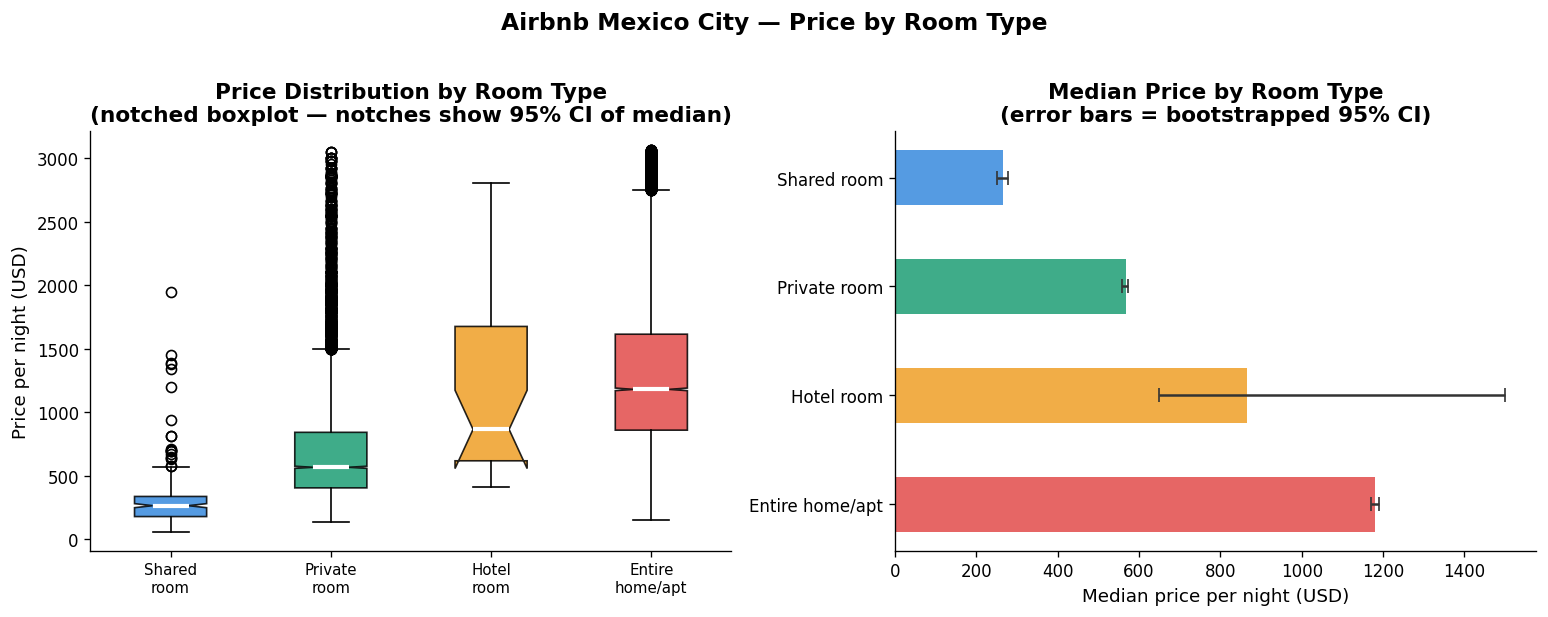

In [4]:
room_order = ['Shared room', 'Private room', 'Hotel room', 'Entire home/apt']
palette = [BLUE, GREEN, AMBER, RED]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
plot_data = [df[df['room_type'] == r]['price_usd'].values for r in room_order
             if r in df['room_type'].unique()]
valid_rooms = [r for r in room_order if r in df['room_type'].unique()]

bp = axes[0].boxplot(plot_data, patch_artist=True, notch=True,
                      medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[0].set_xticklabels([r.replace(' ', '\n') for r in valid_rooms], fontsize=9)
axes[0].set_ylabel('Price per night (USD)')
axes[0].set_title('Price Distribution by Room Type\n(notched boxplot — notches show 95% CI of median)')

# Median + CI bar chart
medians, ci_lows, ci_highs = [], [], []
for room in valid_rooms:
    sub = df[df['room_type'] == room]['price_usd']
    med = sub.median()
    # Bootstrap 95% CI for the median
    boot_medians = [np.median(np.random.choice(sub, size=len(sub), replace=True))
                    for _ in range(1000)]
    medians.append(med)
    ci_lows.append(med - np.percentile(boot_medians, 2.5))
    ci_highs.append(np.percentile(boot_medians, 97.5) - med)

axes[1].barh(valid_rooms[::-1], medians[::-1],
             xerr=[ci_lows[::-1], ci_highs[::-1]],
             color=palette[::-1], alpha=0.85, height=0.5,
             error_kw=dict(ecolor='#333', capsize=4, lw=1.5))
axes[1].set_xlabel('Median price per night (USD)')
axes[1].set_title('Median Price by Room Type\n(error bars = bootstrapped 95% CI)')

plt.suptitle('Airbnb Mexico City — Price by Room Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/price_by_room_type.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.2 Hypothesis test: do room types have different price distributions?

**H₀:** The price distributions of all room types are identical  
**H₁:** At least one room type has a different price distribution  
**Test:** Kruskal-Wallis (non-parametric ANOVA) — chosen because price is not normally distributed  
**α = 0.05**

In [5]:
groups = [df[df['room_type'] == r]['price_usd'].values
          for r in df['room_type'].unique()]

stat, p_value = stats.kruskal(*groups)

print('=== Kruskal-Wallis Test — Price by Room Type ===')
print(f'  H-statistic : {stat:.4f}')
print(f'  p-value     : {p_value:.2e}')
print()
if p_value < 0.05:
    print('  ✓ REJECT H₀ — Room type has a statistically significant effect on price (p < 0.05).')
    print('  At least one room type has a meaningfully different price distribution.')
else:
    print('  FAIL TO REJECT H₀ — No significant difference detected.')

=== Kruskal-Wallis Test — Price by Room Type ===
  H-statistic : 5841.9254
  p-value     : 0.00e+00

  ✓ REJECT H₀ — Room type has a statistically significant effect on price (p < 0.05).
  At least one room type has a meaningfully different price distribution.


In [6]:
# Post-hoc: pairwise Mann-Whitney U tests between room types
from itertools import combinations

room_types = df['room_type'].unique()
results = []

for r1, r2 in combinations(room_types, 2):
    g1 = df[df['room_type'] == r1]['price_usd']
    g2 = df[df['room_type'] == r2]['price_usd']
    stat_mw, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    results.append({
        'comparison': f'{r1}  vs  {r2}',
        'median_1': f'${g1.median():.0f}',
        'median_2': f'${g2.median():.0f}',
        'p_value': round(p_mw, 4),
        'significant': '✓' if p_mw < 0.05 else '✗'
    })

pd.DataFrame(results)

,comparison,median_1,median_2,p_value,significant
0,Entire home/apt vs Private room,$1180,$567,0.0000,✓
1,Entire home/apt vs Hotel room,$1180,$865,0.1402,✗
2,Entire home/apt vs Shared room,$1180,$265,0.0000,✓
3,Private room vs Hotel room,$567,$865,0.0000,✓
4,Private room vs Shared room,$567,$265,0.0000,✓
5,Hotel room vs Shared room,$865,$265,0.0000,✓


## 4. Price by Neighbourhood

### 4.1 Top and bottom neighbourhoods by median price

In [7]:
# Only include neighbourhoods with at least 30 listings for reliable estimates
MIN_LISTINGS = 30

nbhd_stats = (
    df.groupby('neighbourhood_cleansed')['price_usd']
    .agg(['median', 'mean', 'count', 'std'])
    .query(f'count >= {MIN_LISTINGS}')
    .sort_values('median', ascending=False)
)

# Bootstrap CI for median — top and bottom 15 neighbourhoods
def bootstrap_median_ci(series, n_boot=500, ci=95):
    boots = [np.median(np.random.choice(series, size=len(series), replace=True))
             for _ in range(n_boot)]
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return lo, hi

top15 = nbhd_stats.head(15).copy()
bot15 = nbhd_stats.tail(15).copy()

for subset in [top15, bot15]:
    cis = []
    for nbhd in subset.index:
        lo, hi = bootstrap_median_ci(df[df['neighbourhood_cleansed'] == nbhd]['price_usd'])
        cis.append((lo, hi))
    subset['ci_lo'] = [c[0] for c in cis]
    subset['ci_hi'] = [c[1] for c in cis]
    subset['err_lo'] = subset['median'] - subset['ci_lo']
    subset['err_hi'] = subset['ci_hi'] - subset['median']

print(f'Neighbourhoods with ≥{MIN_LISTINGS} listings: {len(nbhd_stats)}')

Neighbourhoods with ≥30 listings: 15


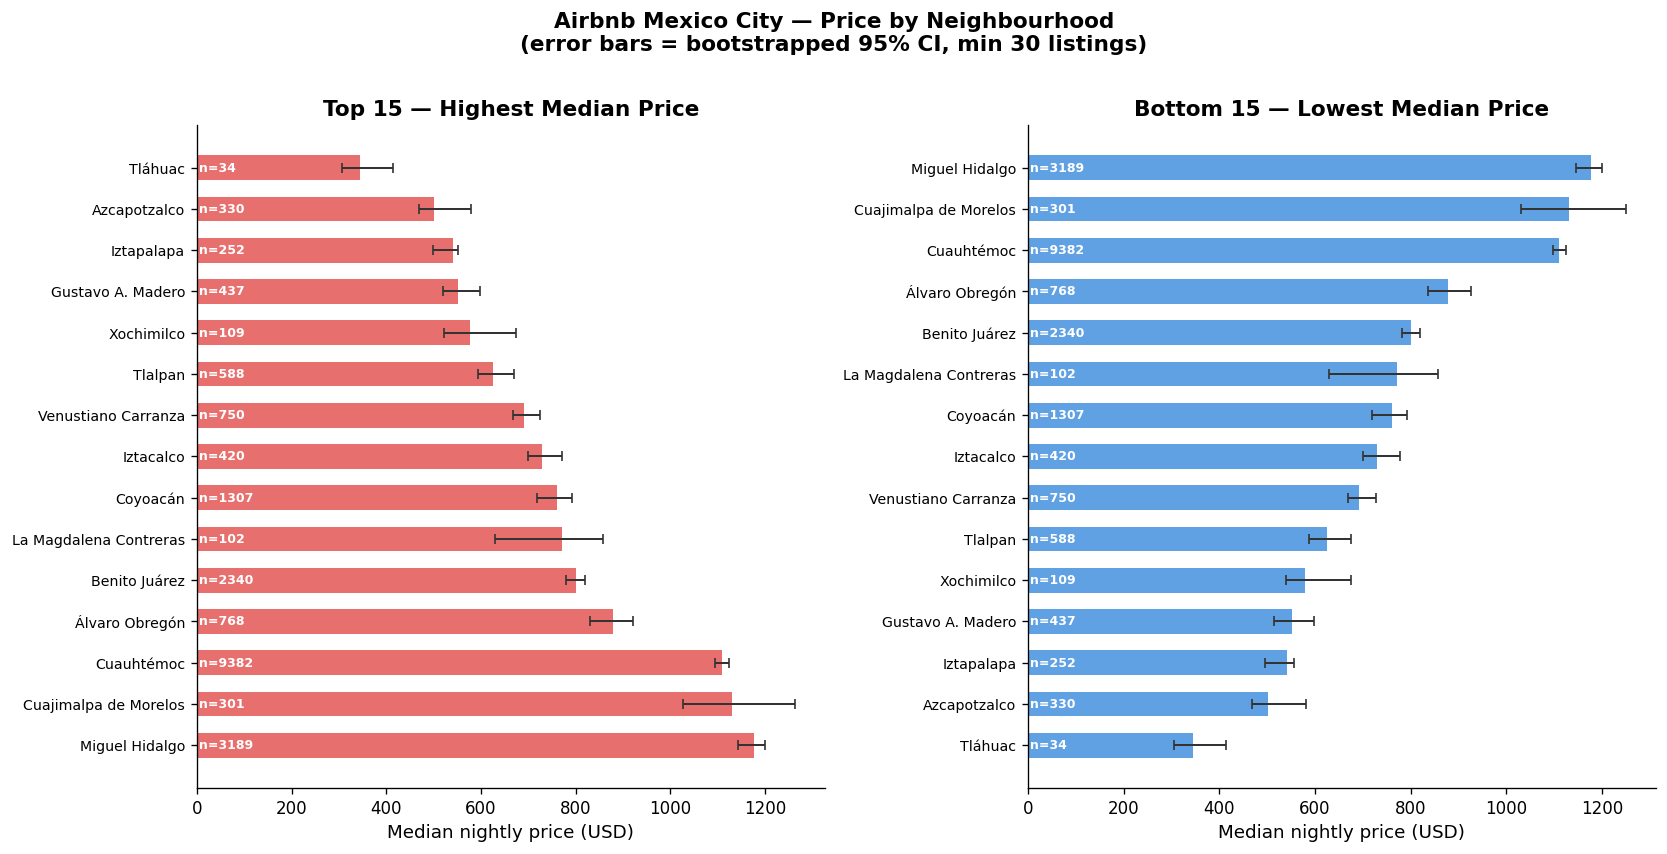

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, subset, title, color in [
    (axes[0], top15, 'Top 15 — Highest Median Price', RED),
    (axes[1], bot15.sort_values('median'), 'Bottom 15 — Lowest Median Price', BLUE)
]:
    ax.barh(subset.index, subset['median'],
            xerr=[subset['err_lo'], subset['err_hi']],
            color=color, alpha=0.8, height=0.6,
            error_kw=dict(ecolor='#333', capsize=3, lw=1.2))
    for i, (nbhd, row) in enumerate(subset.iterrows()):
        ax.text(5, i, f"n={row['count']:.0f}", va='center', fontsize=7.5, color='white',
                fontweight='bold')
    ax.set_xlabel('Median nightly price (USD)')
    ax.set_title(title)
    ax.tick_params(axis='y', labelsize=8.5)

plt.suptitle('Airbnb Mexico City — Price by Neighbourhood\n(error bars = bootstrapped 95% CI, min 30 listings)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/price_by_neighbourhood.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Continuous Features vs Price

### 5.1 Correlation matrix

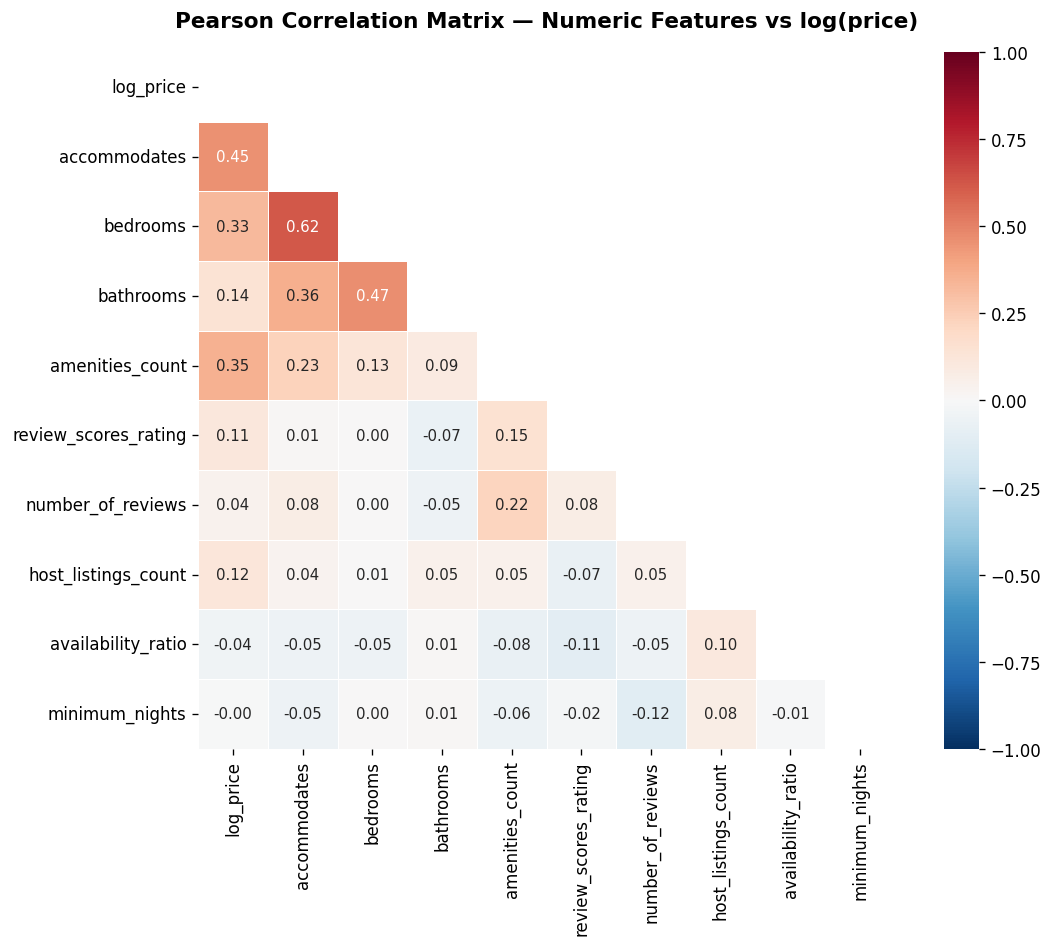


Correlations with log_price (sorted):
accommodates            0.455
amenities_count         0.352
bedrooms                0.326
bathrooms               0.143
host_listings_count     0.120
review_scores_rating    0.114
number_of_reviews       0.045
minimum_nights         -0.005
availability_ratio     -0.042
Name: log_price, dtype: float64


In [9]:
numeric_features = [
    'log_price', 'accommodates', 'bedrooms', 'bathrooms',
    'amenities_count', 'review_scores_rating', 'number_of_reviews',
    'host_listings_count', 'availability_ratio', 'minimum_nights'
]

corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Pearson Correlation Matrix — Numeric Features vs log(price)', pad=15)
plt.tight_layout()
plt.savefig('reports/figures/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Print correlations with log_price sorted
print('\nCorrelations with log_price (sorted):')
print(corr_matrix['log_price'].drop('log_price').sort_values(ascending=False).round(3))

### 5.2 Scatter plots — top correlated features vs log_price

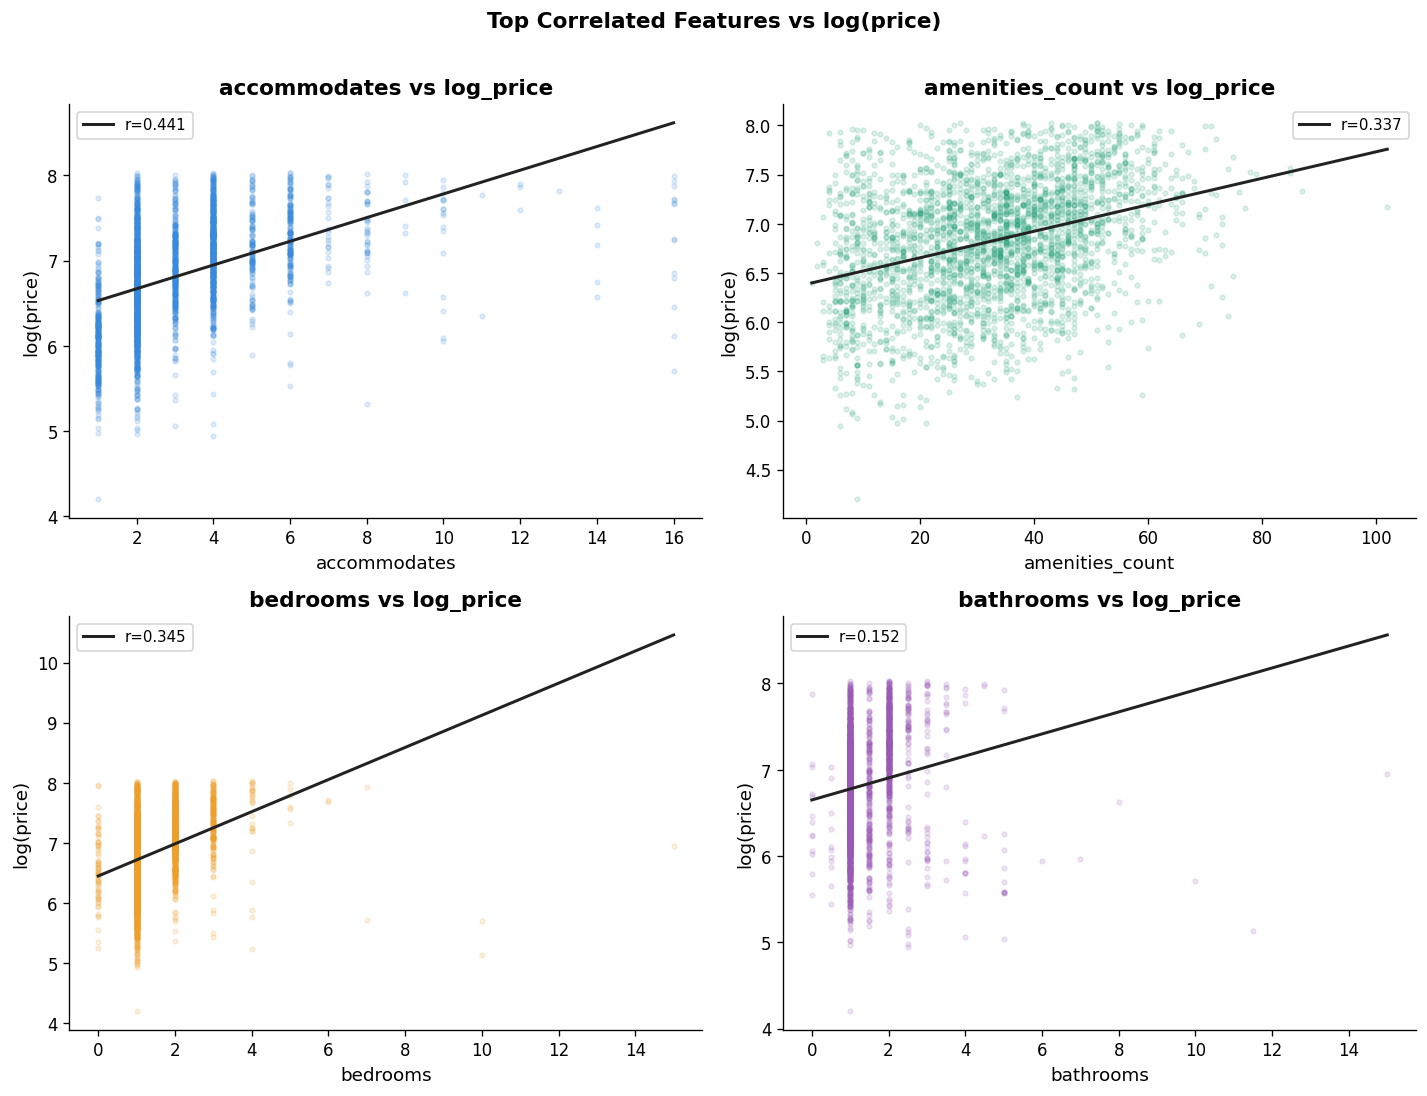

In [10]:
top_corr_features = (
    corr_matrix['log_price']
    .drop('log_price')
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
colors_scatter = [BLUE, GREEN, AMBER, PURPLE]

for ax, feat, color in zip(axes, top_corr_features, colors_scatter):
    # Sample for readability if large dataset
    sample = df[[feat, 'log_price']].dropna().sample(min(3000, len(df)), random_state=42)
    ax.scatter(sample[feat], sample['log_price'],
               alpha=0.15, s=8, color=color)

    # Regression line
    m, b, r, p, _ = stats.linregress(sample[feat], sample['log_price'])
    x_line = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='#222', linewidth=1.8, label=f'r={r:.3f}')

    ax.set_xlabel(feat)
    ax.set_ylabel('log(price)')
    ax.set_title(f'{feat} vs log_price')
    ax.legend(fontsize=9)

plt.suptitle('Top Correlated Features vs log(price)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/scatter_top_features.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.3 Price by number of bedrooms — with confidence intervals

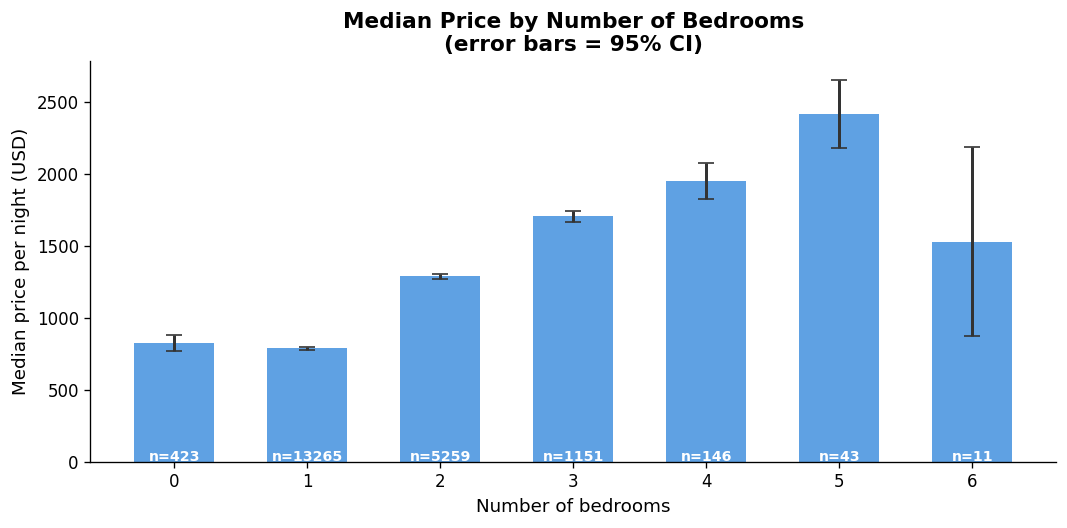

In [11]:
bedroom_price = (
    df[df['bedrooms'] <= 6]
    .groupby('bedrooms')['price_usd']
    .agg(['median', 'count', 'std'])
    .reset_index()
)

# 95% CI using t-distribution
bedroom_price['se'] = bedroom_price['std'] / np.sqrt(bedroom_price['count'])
bedroom_price['ci'] = bedroom_price['se'] * stats.t.ppf(0.975, df=bedroom_price['count']-1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(bedroom_price['bedrooms'], bedroom_price['median'],
       color=BLUE, alpha=0.8, width=0.6)
ax.errorbar(bedroom_price['bedrooms'], bedroom_price['median'],
            yerr=bedroom_price['ci'], fmt='none',
            ecolor='#333', capsize=5, lw=1.8)

for _, row in bedroom_price.iterrows():
    ax.text(row['bedrooms'], 8, f"n={row['count']:.0f}",
            ha='center', fontsize=8.5, color='white', fontweight='bold')

ax.set_xlabel('Number of bedrooms')
ax.set_ylabel('Median price per night (USD)')
ax.set_title('Median Price by Number of Bedrooms\n(error bars = 95% CI)')
ax.set_xticks(bedroom_price['bedrooms'])
plt.tight_layout()
plt.savefig('reports/figures/price_by_bedrooms.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Superhost & Reviews Effect on Price

### 6.1 Hypothesis test: do superhosts charge more?

**H₀:** Price distributions are identical for superhosts and non-superhosts  
**H₁:** Superhosts have a different price distribution  
**Test:** Mann-Whitney U (two-sided)  
**α = 0.05**

In [12]:
superhost_yes = df[df['host_is_superhost'] == True]['price_usd']
superhost_no  = df[df['host_is_superhost'] == False]['price_usd']

stat_mw, p_mw = stats.mannwhitneyu(superhost_yes, superhost_no, alternative='two-sided')

print('=== Mann-Whitney U — Superhost vs Non-Superhost Price ===')
print(f'  Superhost median     : ${superhost_yes.median():.2f}  (n={len(superhost_yes):,})')
print(f'  Non-superhost median : ${superhost_no.median():.2f}  (n={len(superhost_no):,})')
print(f'  U-statistic          : {stat_mw:.1f}')
print(f'  p-value              : {p_mw:.4f}')
print()
if p_mw < 0.05:
    direction = 'higher' if superhost_yes.median() > superhost_no.median() else 'lower'
    print(f'  ✓ REJECT H₀ — Superhost price is statistically significantly {direction} (p < 0.05).')
else:
    print('  FAIL TO REJECT H₀ — No significant price difference detected.')

=== Mann-Whitney U — Superhost vs Non-Superhost Price ===
  Superhost median     : $1050.00  (n=8,465)
  Non-superhost median : $907.00  (n=11,864)
  U-statistic          : 56868836.0
  p-value              : 0.0000

  ✓ REJECT H₀ — Superhost price is statistically significantly higher (p < 0.05).


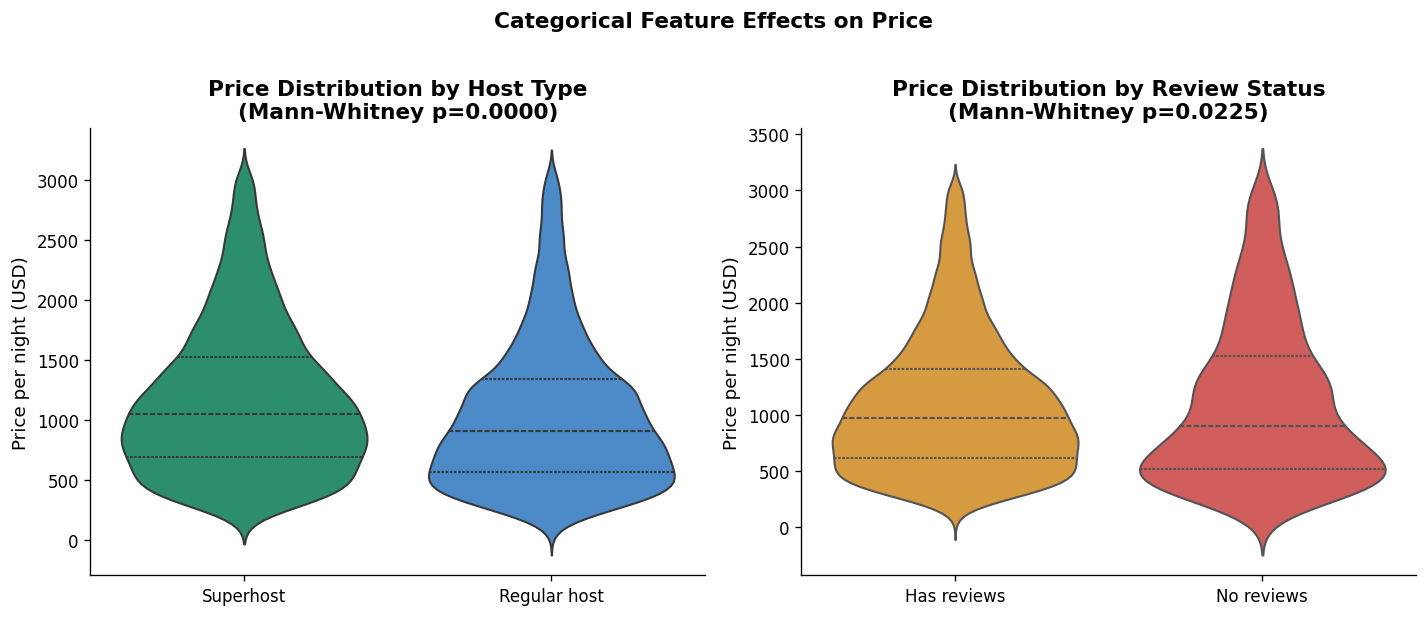

Has reviews median:  $973.00 | No reviews median: $902.00
Reviews p-value: 0.0225


In [13]:
# Visual: violin plot comparing superhost vs non-superhost
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Violin plot
violin_data = df[['host_is_superhost', 'price_usd']].copy()
violin_data['Host type'] = violin_data['host_is_superhost'].map(
    {True: 'Superhost', False: 'Regular host'})

sns.violinplot(data=violin_data, x='Host type', y='price_usd',
               palette={'Superhost': GREEN, 'Regular host': BLUE},
               inner='quartile', ax=axes[0])
axes[0].set_title(f'Price Distribution by Host Type\n(Mann-Whitney p={p_mw:.4f})')
axes[0].set_ylabel('Price per night (USD)')
axes[0].set_xlabel('')

# Has reviews vs no reviews
rev_yes = df[df['has_reviews'] == 1]['price_usd']
rev_no  = df[df['has_reviews'] == 0]['price_usd']
stat_rev, p_rev = stats.mannwhitneyu(rev_yes, rev_no, alternative='two-sided')

violin_data2 = df[['has_reviews', 'price_usd']].copy()
violin_data2['Review status'] = violin_data2['has_reviews'].map(
    {1: 'Has reviews', 0: 'No reviews'})

sns.violinplot(data=violin_data2, x='Review status', y='price_usd',
               palette={'Has reviews': AMBER, 'No reviews': RED},
               inner='quartile', ax=axes[1])
axes[1].set_title(f'Price Distribution by Review Status\n(Mann-Whitney p={p_rev:.4f})')
axes[1].set_ylabel('Price per night (USD)')
axes[1].set_xlabel('')

plt.suptitle('Categorical Feature Effects on Price', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/superhost_reviews_price.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Has reviews median:  ${rev_yes.median():.2f} | No reviews median: ${rev_no.median():.2f}')
print(f'Reviews p-value: {p_rev:.4f}')

## 7. Geospatial Price Distribution

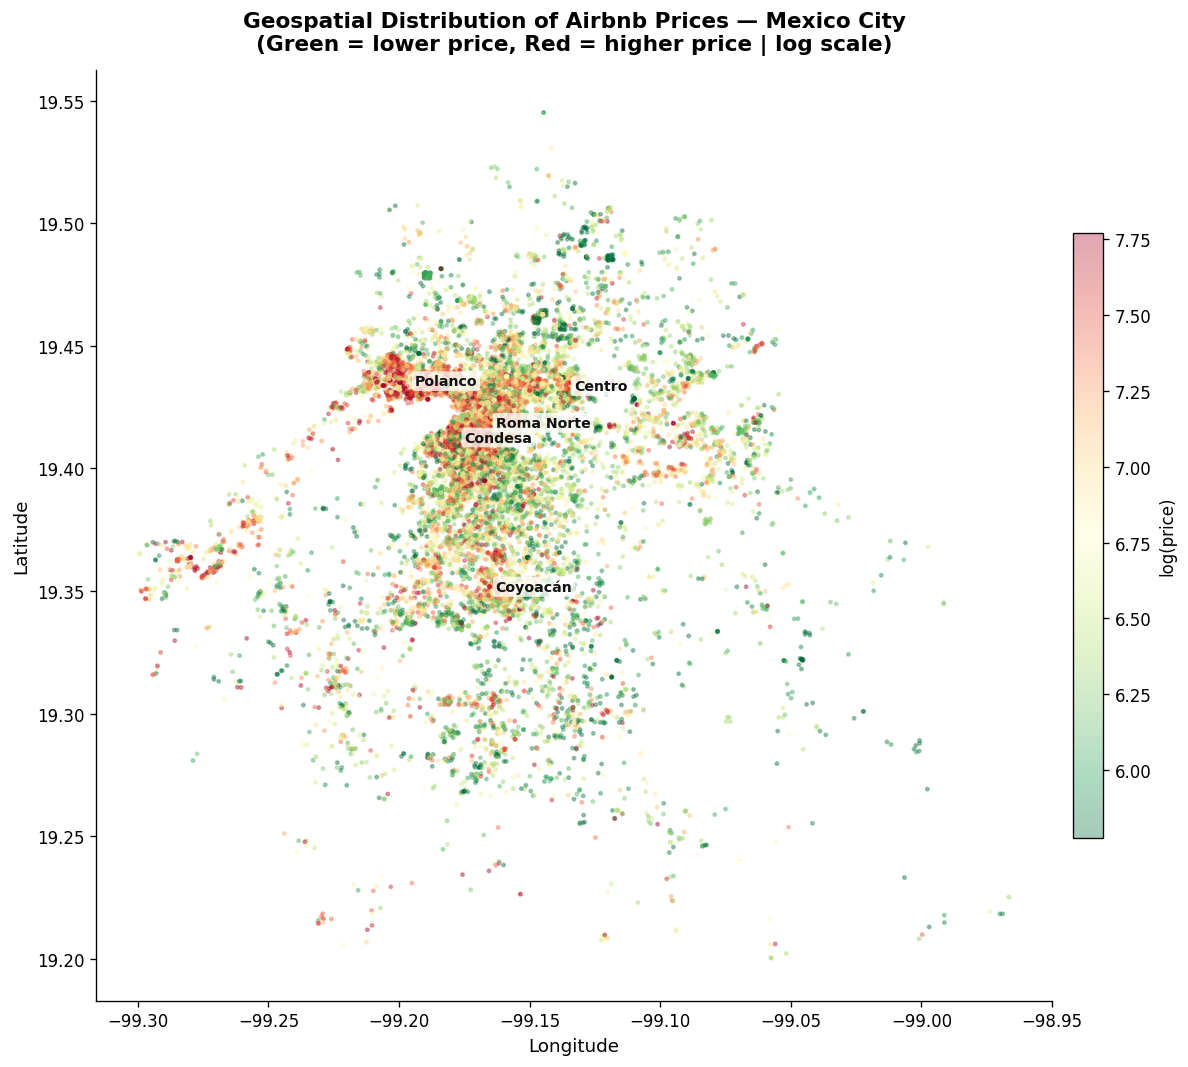

Listings plotted: 20,303


In [14]:
# Filter to valid coordinates (CDMX bounding box)
geo = df[
    df['latitude'].between(19.2, 19.6) &
    df['longitude'].between(-99.3, -98.9)
].copy()

fig, ax = plt.subplots(figsize=(10, 9))

sc = ax.scatter(
    geo['longitude'], geo['latitude'],
    c=geo['log_price'],
    cmap='RdYlGn_r',
    alpha=0.35, s=4,
    vmin=geo['log_price'].quantile(0.05),
    vmax=geo['log_price'].quantile(0.95)
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('log(price)', fontsize=10)

# Annotate approximate key zones
zone_labels = {
    'Polanco':       (-99.194, 19.434),
    'Roma Norte':    (-99.163, 19.417),
    'Condesa':       (-99.175, 19.411),
    'Centro':        (-99.133, 19.432),
    'Coyoacán':      (-99.163, 19.350),
}
for label, (lon, lat) in zone_labels.items():
    ax.annotate(label, (lon, lat), fontsize=8.5, fontweight='bold',
                color='#111',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geospatial Distribution of Airbnb Prices — Mexico City\n'
             '(Green = lower price, Red = higher price | log scale)',
             pad=12)
plt.tight_layout()
plt.savefig('reports/figures/geo_price_map.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Listings plotted: {len(geo):,}')

## 8. Key Statistical Findings Summary

In [15]:
corrs = corr_matrix['log_price'].drop('log_price').sort_values(ascending=False)

print('=' * 60)
print('   EDA STATISTICAL FINDINGS — MEXICO CITY AIRBNB')
print('=' * 60)

print(f"""
1. PRICE OVERVIEW
   Mean price:   ${df['price_usd'].mean():.2f}/night
   Median price: ${df['price_usd'].median():.2f}/night
   Skewness:     {df['price_usd'].skew():.2f} (right-skewed → log transform used)

2. ROOM TYPE EFFECT  (Kruskal-Wallis p < 0.05 ✓)
   Entire home/apt median: ${df[df['room_type']=='Entire home/apt']['price_usd'].median():.0f}
   Private room median:    ${df[df['room_type']=='Private room']['price_usd'].median():.0f}
   Shared room median:     ${df[df['room_type']=='Shared room']['price_usd'].median():.0f}

3. TOP CORRELATED FEATURES WITH log(price)
   {corrs.index[0]:<28}: r = {corrs.iloc[0]:.3f}
   {corrs.index[1]:<28}: r = {corrs.iloc[1]:.3f}
   {corrs.index[2]:<28}: r = {corrs.iloc[2]:.3f}
   {corrs.index[3]:<28}: r = {corrs.iloc[3]:.3f}

4. SUPERHOST PREMIUM  (Mann-Whitney p={p_mw:.4f})
   Superhost median:     ${superhost_yes.median():.2f}
   Non-superhost median: ${superhost_no.median():.2f}
   {'Statistically significant difference detected.' if p_mw < 0.05 else 'No significant difference detected.'}

5. REVIEWS EFFECT  (Mann-Whitney p={p_rev:.4f})
   With reviews median:    ${rev_yes.median():.2f}
   Without reviews median: ${rev_no.median():.2f}
""")
print('=' * 60)
print('Next step → Notebook 04: Regression Model')

   EDA STATISTICAL FINDINGS — MEXICO CITY AIRBNB

1. PRICE OVERVIEW
   Mean price:   $1091.12/night
   Median price: $968.00/night
   Skewness:     0.93 (right-skewed → log transform used)

2. ROOM TYPE EFFECT  (Kruskal-Wallis p < 0.05 ✓)
   Entire home/apt median: $1180
   Private room median:    $567
   Shared room median:     $265

3. TOP CORRELATED FEATURES WITH log(price)
   accommodates                : r = 0.455
   amenities_count             : r = 0.352
   bedrooms                    : r = 0.326
   bathrooms                   : r = 0.143

4. SUPERHOST PREMIUM  (Mann-Whitney p=0.0000)
   Superhost median:     $1050.00
   Non-superhost median: $907.00
   Statistically significant difference detected.

5. REVIEWS EFFECT  (Mann-Whitney p=0.0225)
   With reviews median:    $973.00
   Without reviews median: $902.00

Next step → Notebook 04: Regression Model


---

## Figures generated

| File | Content |
|---|---|
| `price_by_room_type.png` | Boxplot + bootstrapped CI by room type |
| `price_by_neighbourhood.png` | Top/bottom 15 neighbourhoods with CI |
| `correlation_heatmap.png` | Pearson correlation matrix |
| `scatter_top_features.png` | Scatter plots of top correlated features |
| `price_by_bedrooms.png` | Median price per bedroom count with CI |
| `superhost_reviews_price.png` | Violin plots for categorical features |
| `geo_price_map.png` | Geospatial price distribution map |

**Next step →** `04_regression_model.ipynb`